In [1]:
# Install required packages
#!pip install scikit-learn matplotlib

# Import libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import mnist


# Load and subset data

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape((x_train.shape[0], -1)) / 255.0
x_test = x_test.reshape((x_test.shape[0], -1)) / 255.0

# Subsample training data for faster computation
subset_idx = np.random.choice(len(x_train), size=5000, replace=False)
x_train_small = x_train[subset_idx]
y_train_small = y_train[subset_idx]

# Train/validation split (10%)
x_train_main, x_val, y_train_main, y_val = train_test_split(
    x_train_small, y_train_small, test_size=0.1, stratify=y_train_small, random_state=42)

# Standardize
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_main)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# Grid search (fine tuning)

In [3]:
svc = SVC(probability=True)
param_grid = {
    'C': [1, 10],
    'gamma': ['scale', 0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(svc, param_grid, cv=3, scoring='accuracy', verbose=2)
grid.fit(x_train_scaled, y_train_main)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)


Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=  24.5s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=  13.5s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=  13.1s
[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time=  31.1s
[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time=  31.9s
[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time=  31.1s
[CV] END ......................C=10, gamma=scale, kernel=rbf; total time=  11.9s
[CV] END ......................C=10, gamma=scale, kernel=rbf; total time=  12.3s
[CV] END ......................C=10, gamma=scale, kernel=rbf; total time=  12.3s
[CV] END .......................C=10, gamma=0.01, kernel=rbf; total time=  31.1s
[CV] END .......................C=10, gamma=0.01, kernel=rbf; total time=  31.9s
[CV] END .......................C=10, gamma=0.01,

# Evaluate on test set

Test Accuracy: 0.9347
F1 Score: 0.9346
AUC Score: 0.9971


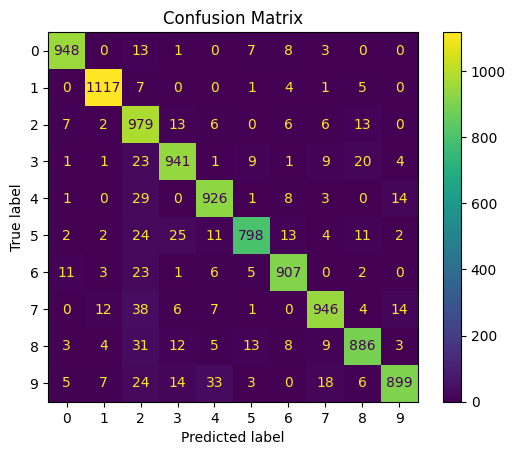

In [4]:
y_pred = best_model.predict(x_test_scaled)
y_proba = best_model.predict_proba(x_test_scaled)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
y_test_bin = label_binarize(y_test, classes=np.arange(10))
auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')

print(f"Test Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC Score: {auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap='viridis')
plt.title("Confusion Matrix")
plt.show()


Sensitivity Analysis

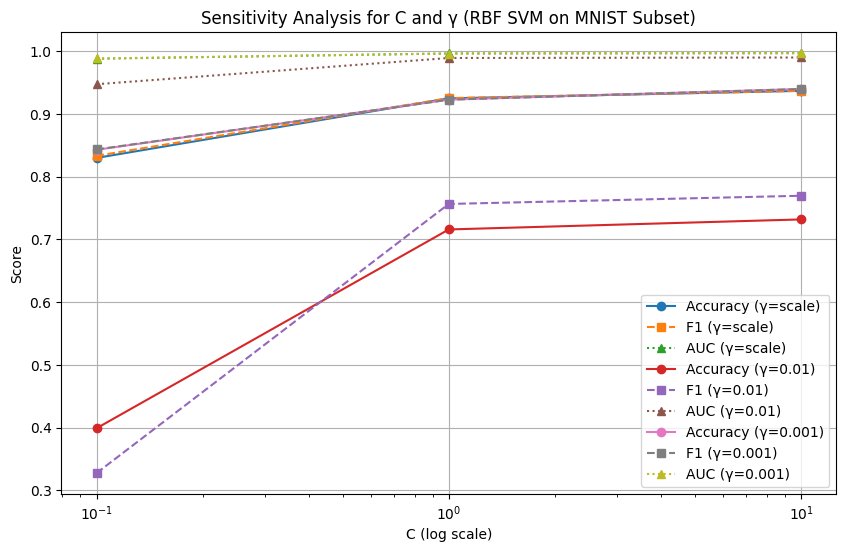

In [5]:
C_values = [0.1, 1, 10]
gamma_values = ['scale', 0.01, 0.001]
results = {g: {'acc': [], 'f1': [], 'auc': []} for g in gamma_values}

# Use fixed train/test split from earlier
X_train, X_test, y_train, y_test = train_test_split(
    x_train_small, y_train_small, test_size=0.2, stratify=y_train_small, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_test_bin = label_binarize(y_test, classes=np.unique(y_train_small))

for gamma in gamma_values:
    for C in C_values:
        model = SVC(C=C, gamma=gamma, kernel='rbf', probability=True)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)

        results[gamma]['acc'].append(accuracy_score(y_test, y_pred))
        results[gamma]['f1'].append(f1_score(y_test, y_pred, average='macro'))
        results[gamma]['auc'].append(roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr'))

# Plot results
plt.figure(figsize=(10, 6))
for gamma in gamma_values:
    plt.plot(C_values, results[gamma]['acc'], marker='o', label=f'Accuracy (γ={gamma})')
    plt.plot(C_values, results[gamma]['f1'], marker='s', linestyle='--', label=f'F1 (γ={gamma})')
    plt.plot(C_values, results[gamma]['auc'], marker='^', linestyle=':', label=f'AUC (γ={gamma})')

plt.xscale('log')
plt.xlabel("C (log scale)")
plt.ylabel("Score")
plt.title("Sensitivity Analysis for C and γ (RBF SVM on MNIST Subset)")
plt.legend()
plt.grid(True)
plt.show()


# Findings

The regularization parameter (C) and gamma noticeably contribute to model performance. As C increases, the performance increased across the board (F1, Accuracy, AUC). When gamma is increased to higher values, the performance seems to be pretty consistent across all metrics.